# Model Evaluation: ResNet50 Classifier (15 Epochs)

Testing the trained classifier on the test dataset.

In [1]:
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Configuration
IMAGE_SIZE = 224
BATCH_SIZE = 8
BASE_PATH = Path.cwd() / 'split_dataset'

print(f"TensorFlow version: {tf.__version__}")
print(f"Dataset path: {BASE_PATH}")
print(f"Path exists: {BASE_PATH.exists()}")

TensorFlow version: 2.20.0
Dataset path: C:\Users\Paudel\Desktop\techsprint_xhack\ml-app\split_dataset
Path exists: True


In [ ]:
MODEL_PATH = Path.cwd() / 'model-training' / 'resnet50_classifier_15epochs.keras'

print(f"Loading model from: {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")

import zipfile
import tempfile
import os
import h5py

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model

def build_classifier_model(image_size=224):
    """Rebuild the ResNet50 classifier architecture matching the original training."""
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(image_size, image_size, 3)
    )
    
    for layer in base_model.layers:
        layer.trainable = False
    for layer in base_model.layers[-30:]:
        layer.trainable = True
    
    x = base_model.output
    x = GlobalAveragePooling2D(name='global_average_pooling2d')(x)
    x = BatchNormalization(name='batch_normalization')(x)
    x = Dense(512, activation='relu', name='dense')(x)
    x = Dropout(0.5, name='dropout')(x)
    x = Dense(256, activation='relu', name='dense_1')(x)
    x = Dropout(0.3, name='dropout_1')(x)
    x = Dense(1, activation='sigmoid', name='dense_2')(x)
    
    model = Model(inputs=base_model.input, outputs=x, name='ResNet50_Classifier')
    return model

print("Building model architecture...")
classifier_model = build_classifier_model(IMAGE_SIZE)

print("Loading trained classification head weights...")
with tempfile.TemporaryDirectory() as tmpdir:
    with zipfile.ZipFile(MODEL_PATH, 'r') as zip_ref:
        zip_ref.extractall(tmpdir)
    
    weights_path = os.path.join(tmpdir, 'model.weights.h5')
    head_layer_names = ['global_average_pooling2d', 'batch_normalization', 'dense', 'dense_1', 'dense_2']
    
    with h5py.File(weights_path, 'r') as f:
        layers_group = f['layers']
        
        for layer_name in head_layer_names:
            try:
                layer = classifier_model.get_layer(layer_name)
                expected_weights = layer.get_weights()
                
                if len(expected_weights) == 0:
                    continue
                
                if layer_name in layers_group and 'vars' in layers_group[layer_name]:
                    vars_g = layers_group[layer_name]['vars']
                    new_weights = [np.array(vars_g[str(i)]) for i in range(len(expected_weights)) if str(i) in vars_g]
                    
                    if len(new_weights) == len(expected_weights):
                        if all(nw.shape == ew.shape for nw, ew in zip(new_weights, expected_weights)):
                            layer.set_weights(new_weights)
                            print(f"   {layer_name}: loaded")
                        else:
                            print(f"   {layer_name}: shape mismatch")
                            for i, (nw, ew) in enumerate(zip(new_weights, expected_weights)):
                                print(f"      weight[{i}]: saved={nw.shape} vs expected={ew.shape}")
                else:
                    print(f"   {layer_name}: not found in weights file")
            except Exception as e:
                print(f"   {layer_name}: {e}")

classifier_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(f"\nClassifier model ready!")
print(f"   ResNet backbone: ImageNet pretrained")  
print(f"   Classification head: Loaded from 15-epoch training")
print(f"   Input shape: {classifier_model.input_shape}")
print(f"   Output shape: {classifier_model.output_shape}")
print(f"   Total params: {classifier_model.count_params():,}")

dense_layer = classifier_model.get_layer('dense')
weights = dense_layer.get_weights()
if len(weights) > 0:
    print(f"\nDense layer weight verification:")
    print(f"   Kernel shape: {weights[0].shape}")
    print(f"   Kernel std: {np.std(weights[0]):.4f}")
    print(f"   Kernel range: [{weights[0].min():.4f}, {weights[0].max():.4f}]")

Loading model from: C:\Users\Paudel\Desktop\techsprint_xhack\ml-app\model-training\resnet50_classifier_15epochs.keras
Model exists: True
🔄 Building model architecture (with ImageNet base)...
🔄 Loading trained classification head weights...
   ⚠️ batch_normalization: shape mismatch
      weight[0]: saved=(64,) vs expected=(2048,)
      weight[1]: saved=(64,) vs expected=(2048,)
      weight[2]: saved=(64,) vs expected=(2048,)
      weight[3]: saved=(64,) vs expected=(2048,)
   ✅ dense: loaded
   ✅ dense_1: loaded
   ✅ dense_2: loaded

✅ Classifier model ready!
   ResNet backbone: ImageNet pretrained
   Classification head: Loaded from 15-epoch training
   Input shape: (None, 224, 224, 3)
   Output shape: (None, 1)
   Total params: 24,776,577

🔍 Dense layer weight verification:
   Kernel shape: (2048, 512)
   Kernel std: 0.0288
   Kernel range: [-0.0779, 0.0789]


In [ ]:
def load_single_image(path, size):
    """Load and preprocess a single image using PIL for TIFF compatibility."""
    with Image.open(path) as img:
        img = img.convert('RGB').resize((size, size))
        return np.array(img, dtype=np.float32) / 255.0

def _load_image_py(path):
    """Helper for tf.numpy_function to decode bytes -> path string."""
    if isinstance(path, (bytes, np.bytes_)):
        path = path.decode('utf-8')
    elif isinstance(path, np.ndarray):
        path = path.item()
        if isinstance(path, (bytes, np.bytes_)):
            path = path.decode('utf-8')
    return load_single_image(path, IMAGE_SIZE)

def build_classifier_dataset(data, batch_size, training=False):
    """Build a tf.data.Dataset for classification."""
    paths = [p for p, _ in data]
    labels = [l for _, l in data]
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        shuffle_buf = min(len(paths), 4096)
        dataset = dataset.shuffle(buffer_size=shuffle_buf, reshuffle_each_iteration=True)

    def _tf_parse(path, label):
        image = tf.numpy_function(func=_load_image_py, inp=[path], Tout=tf.float32)
        image.set_shape((IMAGE_SIZE, IMAGE_SIZE, 3))
        label = tf.cast(label, tf.float32)
        label = tf.reshape(label, [1])
        return image, label

    dataset = dataset.map(_tf_parse, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

print("Helper functions defined")

✅ Helper functions defined


In [ ]:
valid_exts = ['.tif', '.jpg', '.png', '.jpeg', '.bmp']

test_au = [str(f) for f in (BASE_PATH / 'test' / 'Au').glob('*') if f.suffix.lower() in valid_exts]
test_tp = [str(f) for f in (BASE_PATH / 'test' / 'Tp').glob('*') if f.suffix.lower() in valid_exts]

print(f"Test Authentic images: {len(test_au)}")
print(f"Test Tampered images: {len(test_tp)}")
print(f"Total test images: {len(test_au) + len(test_tp)}")

test_data = [(p, 0) for p in test_au] + [(p, 1) for p in test_tp]

test_ds = build_classifier_dataset(test_data, BATCH_SIZE, training=False)
print(f"\nTest dataset created")

Test Authentic images: 337
Test Tampered images: 839
Total test images: 1176

✅ Test dataset created


In [ ]:
print("Running predictions on test data...")
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    preds = classifier_model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_prob.extend(preds.flatten())
    y_pred.extend((preds > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print(f"Predictions complete!")
print(f"   Total samples: {len(y_true)}")

Running predictions on test data...
✅ Predictions complete!
   Total samples: 1176


In [10]:
import pandas as pd

df = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred,
    'y_prob': y_prob
})

print(f"DataFrame shape: {df.shape}")
df.head(10)

DataFrame shape: (1176, 3)


,y_true,y_pred,y_prob
0,0.0,1,0.566862
1,0.0,1,0.566494
2,0.0,1,0.568538
3,0.0,1,0.567721
4,0.0,1,0.568078
5,0.0,1,0.567025
6,0.0,1,0.568323
7,0.0,1,0.567533
8,0.0,1,0.568532
9,0.0,1,0.567244


In [12]:
df['y_pred'].unique()

array([1])

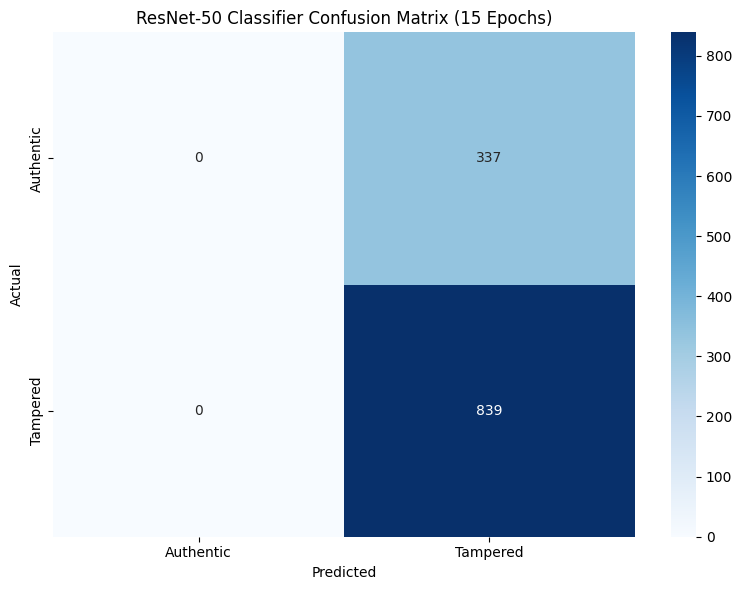


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Authentic       0.00      0.00      0.00       337
    Tampered       0.71      1.00      0.83       839

    accuracy                           0.71      1176
   macro avg       0.36      0.50      0.42      1176
weighted avg       0.51      0.71      0.59      1176



C:\Users\Paudel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Paudel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Paudel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Authentic', 'Tampered'],
            yticklabels=['Authentic', 'Tampered'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ResNet-50 Classifier Confusion Matrix (15 Epochs)')
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Authentic', 'Tampered']))

In [14]:
# Additional metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

print("="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {roc_auc:.4f}")
print("="*60)

MODEL PERFORMANCE SUMMARY
   Accuracy:  0.7134 (71.34%)
   Precision: 0.7134
   Recall:    1.0000
   F1-Score:  0.8328
   ROC-AUC:   0.5097


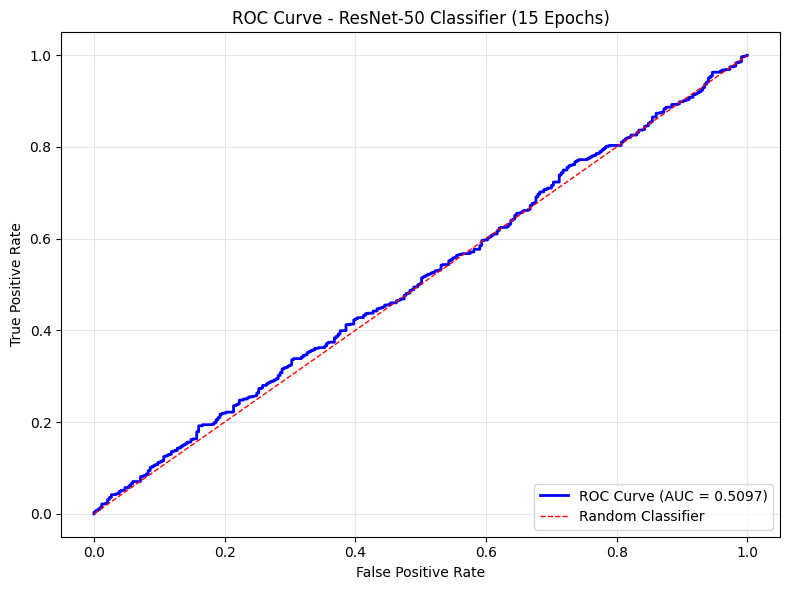

In [15]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ResNet-50 Classifier (15 Epochs)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()